In [1]:
import numpy as np
import xarray as xr
import weatherbenchX
from weatherbenchX.data_loaders import xarray_loaders
from weatherbenchX.metrics import deterministic, spatial
from weatherbenchX.metrics import base as metrics_base
from weatherbenchX import aggregation
from weatherbenchX import weighting
from weatherbenchX import binning
from weatherbenchX import time_chunks

In [2]:
### DEFAULTS ###
# This config will be applied to the data before any plotting. The data will be
# sliced and indexed according to the values in this config.

# Path to the Ground Truth data (in zarr format!)
PATH_ML = DEFAULT_PATH = "/iopsstor/scratch/cscs/sadamov/pyprojects_data/swissai/preds_20250219/aurora.zarr"
PATH_ML = "/capstor/store/cscs/swissai/a01/ESFM_Results/preds_20250219/aurora_tail.zarr"
PATH_NWP = "/capstor/store/cscs/ERA5/weatherbench2_original"
# Selection of vertical levels
LEVELS = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
# Temporal resolution in hours.
TEMPORAL_RESOLUTION = 1
# Selection of time steps (e.g. ["2021-01-01T06", "2021-01-05T00"], or [None,
# None])
DATETIMES = ["2021-01-01T12", "2021-02-01T06"]
# Selection of latitude and longitude
LATITUDES = [90.0, -89.75]
LONGITUDES = [0.0, 359.75]
# Variables to be plotted, 2D and 3D variables are treated separately
# Dims - 2D: time, latitude, longitude; 3D: time, latitude, longitude, level
VARIABLES_2D = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "mean_sea_level_pressure",
]
VARIABLES_3D = [
    "geopotential",
    "specific_humidity",
    "temperature",
    "u_component_of_wind",
    "v_component_of_wind",
]
# If the model has probabilistic output, choose one member here
# Otherwise the setting will be ignored. In the future probabilistic
# verification will be implemented.
ENSEMBLE_MEMBER = 0
# Usually model data has no missing values, but if it might, set this to True
CHECK_MISSING_VALUES = False
# For some plots a random time step sample is selected
RANDOM_SEED = 42
TIME_SUBSAMPLES = 10
DPI = 48

In [3]:
ds_clima = xr.open_zarr("/capstor/store/cscs/swissai/a01/ERA5-climatology-1990-2019-surface-6h.zarr")
ds_clima = ds_clima.sel(latitude=ds_clima.latitude[:720])
ds_clima

<xarray.Dataset> Size: 134GB
Dimensions:                                      (hour: 4, dayofyear: 366,
                                                  latitude: 720, longitude: 1440)
Coordinates:
  * dayofyear                                    (dayofyear) int64 3kB 1 ... 366
  * hour                                         (hour) int64 32B 0 6 12 18
  * latitude                                     (latitude) float32 3kB 90.0 ...
  * longitude                                    (longitude) float32 6kB 0.0 ...
Data variables: (12/22)
    10m_u_component_of_wind                      (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    10m_v_component_of_wind                      (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    2m_temperature                               (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    mean_sea_level_pressure                      (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    mean_surface_latent_heat_flux                (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    mean_surface_net_long_wave_radiation_flux    (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    ...                                           ...
    total_precipitation_6hr_seeps_dry_fraction   (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    total_precipitation_6hr_seeps_threshold      (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    volumetric_soil_water_layer_1                (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    volumetric_soil_water_layer_2                (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    volumetric_soil_water_layer_3                (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>
    volumetric_soil_water_layer_4                (hour, dayofyear, latitude, longitude) float32 6GB dask.array<chunksize=(3, 3, 720, 1440), meta=np.ndarray>

In [4]:
ds = xr.open_zarr(PATH_NWP)
land_sea_mask = ds["land_sea_mask"][:720].compute()
ds

<xarray.Dataset> Size: 534TB
Dimensions:                                           (time: 552264,
                                                       latitude: 721,
                                                       longitude: 1440,
                                                       level: 37)
Coordinates:
  * latitude                                          (latitude) float32 3kB ...
  * level                                             (level) int64 296B 1 .....
  * longitude                                         (longitude) float32 6kB ...
  * time                                              (time) datetime64[ns] 4MB ...
Data variables: (12/31)
    10m_u_component_of_wind                           (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                           (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_temperature                                    (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    geopotential                                      (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(1, 37, 721, 1440), meta=np.ndarray>
    ...                                                ...
    total_precipitation                               (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    type_of_high_vegetation                           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    type_of_low_vegetation                            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    u_component_of_wind                               (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(1, 37, 721, 1440), meta=np.ndarray>
    v_component_of_wind                               (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(1, 37, 721, 1440), meta=np.ndarray>
    vertical_velocity                                 (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(1, 37, 721, 1440), meta=np.ndarray>

In [5]:
ds = xr.open_zarr(PATH_NWP)
print(ds)
ds = ds.sel(
    level=LEVELS,
    latitude=slice(*LATITUDES),
    longitude=slice(*LONGITUDES),
    time=slice(*DATETIMES),
)
if "ensemble" in ds.dims:
    ds = ds.isel(ensemble=ENSEMBLE_MEMBER)
ds = ds[VARIABLES_2D + VARIABLES_3D]
ds_timestep = int(
    (ds.time.isel(time=1) - ds.time.isel(time=0)).dt.total_seconds() / 3600
)
ds_timestep_factor = TEMPORAL_RESOLUTION // ds_timestep
ds = ds.isel(time=slice(None, None, ds_timestep_factor))
# ds.compute()
ds
# ds = (ds
#  .rename(time="valid_time")
#  .expand_dims(lead_time=np.array([6], dtype="timedelta64[h]"), axis=1)
#  .assign_coords(init_time=lambda x: x["valid_time"] - np.timedelta64(6, "h"))
#  .swap_dims({"valid_time": "init_time"})
#  .assign_coords(valid_time=lambda x: x["valid_time"] - x["lead_time"])
# )

<xarray.Dataset> Size: 534TB
Dimensions:                                           (time: 552264,
                                                       latitude: 721,
                                                       longitude: 1440,
                                                       level: 37)
Coordinates:
  * latitude                                          (latitude) float32 3kB ...
  * level                                             (level) int64 296B 1 .....
  * longitude                                         (longitude) float32 6kB ...
  * time                                              (time) datetime64[ns] 4MB ...
Data variables: (12/31)
    10m_u_component_of_wind                           (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                           (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_temperature               

<xarray.Dataset> Size: 211GB
Dimensions:                  (time: 739, latitude: 720, longitude: 1440,
                              level: 13)
Coordinates:
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
  * time                     (time) datetime64[ns] 6kB 2021-01-01T12:00:00 .....
Data variables:
    10m_u_component_of_wind  (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    mean_sea_level_pressure  (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 40GB dask.array<chunksize=(1, 13, 720, 1440), meta=np.ndarray>
    specific_humidity        (time, level, latitude, longitude) float32 40GB dask.array<chunksize=(1, 13, 720, 1440), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 40GB dask.array<chunksize=(1, 13, 720, 1440), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 40GB dask.array<chunksize=(1, 13, 720, 1440), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 40GB dask.array<chunksize=(1, 13, 720, 1440), meta=np.ndarray>

In [6]:
# with LocalCluster(
#     n_workers=32, threads_per_worker=1, memory_limit="8GB"
# ) as cluster:
#     with Client(cluster) as client:
ds_ml = xr.open_zarr(PATH_ML)
print(ds_ml["time"])
ds_ml = ds_ml.sel(
    level=LEVELS,
    latitude=slice(*LATITUDES),
    longitude=slice(*LONGITUDES),
    time=slice(*DATETIMES),
)
# if "ensemble" in ds_ml.dims:
    # ds_ml = ds_ml.sel(ensemble=ENSEMBLE_MEMBER)
ds_ml = ds_ml[VARIABLES_2D + VARIABLES_3D]
if len(ds.time) > 1:
    ds_ml_timestep = int(
        (ds.time.isel(time=1) - ds.time.isel(time=0)).dt.total_seconds() / 3600
    )
    ds_ml_timestep_factor = TEMPORAL_RESOLUTION // ds_ml_timestep
    ds_ml = ds_ml.isel(time=slice(None, None, ds_ml_timestep_factor))
elif len(ds.time) == 1:
    pass
else:
    raise ValueError("No time stepts selected between the given dates.")
# ds_ml.compute()

ds_ml = (ds_ml
 .rename(time="valid_time")
 .expand_dims(lead_time=np.array([6], dtype="timedelta64[h]").astype("timedelta64[ns]"), axis=1)
 .assign_coords(init_time=lambda x: x["valid_time"] - np.timedelta64(6, "h"))
 .swap_dims({"valid_time": "init_time"})
 .assign_coords(valid_time=lambda x: x["valid_time"] - x["lead_time"])
)
ds_ml

<xarray.DataArray 'time' (time: 739)> Size: 6kB
array(['2021-01-01T12:00:00.000000000', '2021-01-01T13:00:00.000000000',
       '2021-01-01T14:00:00.000000000', ..., '2021-02-01T04:00:00.000000000',
       '2021-02-01T05:00:00.000000000', '2021-02-01T06:00:00.000000000'],
      shape=(739,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 2021-01-01T12:00:00 ... 2021-02-01T06:...


<xarray.Dataset> Size: 2TB
Dimensions:                  (lead_time: 1, init_time: 739, ensemble: 8,
                              latitude: 720, longitude: 1440, level: 13)
Coordinates:
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 6kB 2021-0...
  * init_time                (init_time) datetime64[ns] 6kB 2021-01-01T06:00:...
Data variables:
    10m_u_component_of_wind  (init_time, lead_time, ensemble, latitude, longitude) float32 25GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    10m_v_component_of_wind  (init_time, lead_time, ensemble, latitude, longitude) float32 25GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    2m_temperature           (init_time, lead_time, ensemble, latitude, longitude) float32 25GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    mean_sea_level_pressure  (init_time, lead_time, ensemble, latitude, longitude) float32 25GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    geopotential             (init_time, lead_time, ensemble, level, latitude, longitude) float32 319GB dask.array<chunksize=(1, 1, 8, 13, 720, 1440), meta=np.ndarray>
    specific_humidity        (init_time, lead_time, ensemble, level, latitude, longitude) float32 319GB dask.array<chunksize=(1, 1, 8, 13, 720, 1440), meta=np.ndarray>
    temperature              (init_time, lead_time, ensemble, level, latitude, longitude) float32 319GB dask.array<chunksize=(1, 1, 8, 13, 720, 1440), meta=np.ndarray>
    u_component_of_wind      (init_time, lead_time, ensemble, level, latitude, longitude) float32 319GB dask.array<chunksize=(1, 1, 8, 13, 720, 1440), meta=np.ndarray>
    v_component_of_wind      (init_time, lead_time, ensemble, level, latitude, longitude) float32 319GB dask.array<chunksize=(1, 1, 8, 13, 720, 1440), meta=np.ndarray>

In [7]:
init_times = ds["time"].values[:4].astype("datetime64[ns]")
lead_times = np.array([6], dtype='timedelta64[h]').astype('timedelta64[ns]')   # To silence xr warnings.

target_dataloader = xarray_loaders.TargetsFromXarray(
    ds=ds,
    variables=VARIABLES_2D,
    rename_dimensions={"time": "valid_time"},
    compute=False,
)

pred_dataloader = xarray_loaders.PredictionsFromXarray(
    ds=ds_ml,
    variables=VARIABLES_2D,
    rename_dimensions={},
    compute=False,
)

we: xr.Dataset = pred_dataloader.load_chunk(init_times, lead_times)
we.chunk({"init_time": 1}).persist(scheduler="threads")

<xarray.Dataset> Size: 531MB
Dimensions:                  (init_time: 4, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 32B dask.array<chunksize=(1, 1), meta=np.ndarray>
  * init_time                (init_time) datetime64[ns] 32B 2021-01-01T12:00:...
Data variables:
    10m_u_component_of_wind  (init_time, lead_time, ensemble, latitude, longitude) float32 133MB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    10m_v_component_of_wind  (init_time, lead_time, ensemble, latitude, longitude) float32 133MB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    2m_temperature           (init_time, lead_time, ensemble, latitude, longitude) float32 133MB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    mean_sea_level_pressure  (init_time, lead_time, ensemble, latitude, longitude) float32 133MB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>

In [8]:
from swissclim_evaluations.metrics.wbx import CRPSEnsemble, SpreadSkillRatio
# from swissclim_evaluations.metrics import wbx

In [9]:
metrics = {
  # "RMSE": deterministic.RMSE(),
  # "MAE": deterministic.MAE(),
  # "bias": deterministic.Bias(),
  # "ACC": deterministic.ACC(climatology=ds_clima),
  # "FSS": spatial.FSS(neighborhood_size_in_pixels=11),
  # deterministic.
  "CRPS": CRPSEnsemble(ensemble_dim="ensemble"),
  "SSR": SpreadSkillRatio(ensemble_dim="ensemble"),
}

# define weighting rule
weigh_by = [weighting.GridAreaWeighting()]

# define binning rules
regions = {
    # ((lat_min, lat_max), (lon_min, lon_max))
    "global": ((-90, 90), (0, 360)),
    "southern_extratropics": ((-90, -60), (0, 360)),
    "southern_subtropics": ((-60, -30), (0, 360)),
    "equatorial": ((-30, 30), (0, 360)),
    "northern_subtropics": ((30, 60), (0, 360)),
    "northern_extratropics": ((60, 90), (0, 360)),
}

bin_by = [binning.Regions(regions=regions, land_sea_mask=land_sea_mask), binning.ByTimeUnit("season", "init_time")]
aggregator = aggregation.Aggregator(
    reduce_dims=["latitude", "longitude"],
    bin_by=bin_by,
    weigh_by=weigh_by,
)

In [14]:
from tqdm import tqdm

init_times = ds_ml["init_time"].values[:100]
lead_times = np.array([6], dtype='timedelta64[h]').astype('timedelta64[ns]')

times = time_chunks.TimeChunks(
  init_times,
  lead_times,
  init_time_chunk_size=10,
  lead_time_chunk_size=1
)

results = []
pbar_times = tqdm(times, desc="Computing metrics")
for init_times, lead_times in pbar_times:

  pred_chunk = pred_dataloader.load_chunk(init_times, lead_times)
  target_chunk = target_dataloader.load_chunk(init_times, lead_times)

  

  res_chunk = aggregation.compute_metric_values_for_single_chunk(
    metrics,
    aggregator,
    pred_chunk.chunk({"init_time": 1}).persist(scheduler="threads", num_workers=10),
    target_chunk.chunk({"init_time": 1}).persist(scheduler="threads", num_workers=10),
  )
  results.append(res_chunk)

results = xr.merge(results)
  

Computing metrics: 100%|██████████| 10/10 [01:44<00:00, 10.43s/it]


In [15]:
results

<xarray.Dataset> Size: 41kB
Dimensions:                       (init_time: 100, lead_time: 1, region: 12,
                                   init_time_season: 1)
Coordinates:
  * init_time                     (init_time) datetime64[ns] 800B 2021-01-01T...
  * lead_time                     (lead_time) timedelta64[ns] 8B 06:00:00
  * region                        (region) <U26 1kB 'global' ... 'northern_ex...
  * init_time_season              (init_time_season) <U3 12B 'DJF'
    valid_time                    (init_time, lead_time) datetime64[ns] 800B ...
Data variables:
    CRPS.10m_u_component_of_wind  (init_time, lead_time, region, init_time_season) float32 5kB ...
    CRPS.2m_temperature           (init_time, lead_time, region, init_time_season) float32 5kB ...
    CRPS.mean_sea_level_pressure  (init_time, lead_time, region, init_time_season) float32 5kB ...
    CRPS.10m_v_component_of_wind  (init_time, lead_time, region, init_time_season) float32 5kB ...
    SSR.10m_u_component_of_wind   (init_time, lead_time, region, init_time_season) float32 5kB ...
    SSR.2m_temperature            (init_time, lead_time, region, init_time_season) float32 5kB ...
    SSR.mean_sea_level_pressure   (init_time, lead_time, region, init_time_season) float32 5kB ...
    SSR.10m_v_component_of_wind   (init_time, lead_time, region, init_time_season) float32 5kB ...

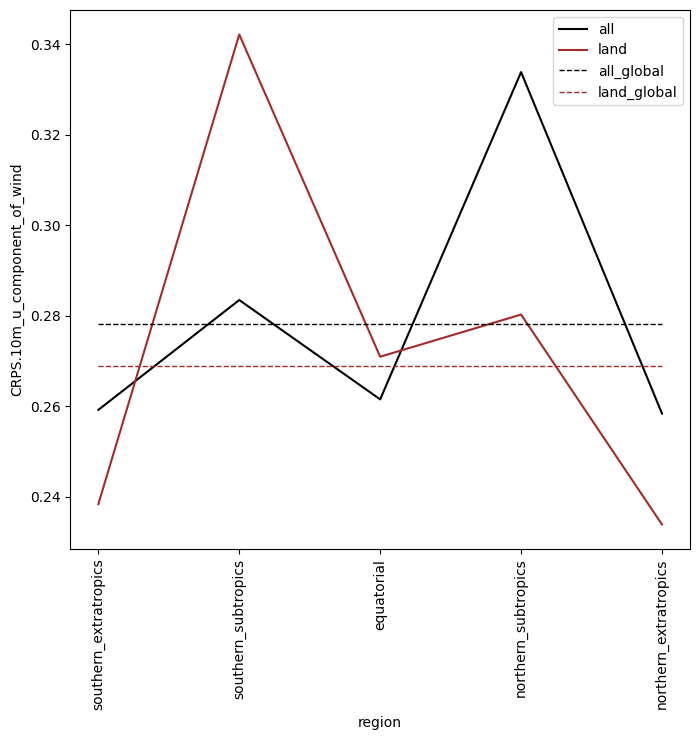

In [91]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(8,7))
land = results.mean(["init_time", "lead_time", "init_time_season"])["CRPS.10m_u_component_of_wind"].sel(region=[r.item() for r in results["region"] if "_land" in r.item()])
full = results.mean(["init_time", "lead_time", "init_time_season"])["CRPS.10m_u_component_of_wind"].sel(region=[r.item() for r in results["region"] if "_land" not in r.item()])
# results.mean(["init_time", "init_time_season"])
land = land.assign_coords(region=[r.item() for r in full["region"]])

# orientation of xlabels must be vertical
full[1:].plot(ax=ax, label="all", color="black")
land[1:].plot(ax=ax, label="land", color="brown")
ax.hlines(full[0].values, 0, len(full["region"][1:])-1, ls="--", ec="k", lw=1, label="all_global")
ax.hlines(land[0].values, 0, len(land["region"][1:])-1, ls="--", ec="brown", lw=1, label="land_global")
plt.xticks(rotation=90)
# results
plt.legend()
# [r.item() for r in results["region"]]


In [82]:
full["region"][0].values

array('global', dtype='<U26')

In [71]:
def _crps_ensemble_fair(obs, fct):
    M: int = fct.shape[-1]
    e_1 = np.sum(np.abs(obs[..., None] - fct), axis=-1) / M
    e_2 = np.sum(
        np.abs(fct[..., None] - fct[..., None, :]),
        axis=(-1, -2),
    ) / (M * (M - 1))
    return e_1 - 0.5 * e_2

def crps_ensemble(obs, fct):
    """Compute the CRPS for ensemble forecasts."""
    # Compute the CRPS for each ensemble member
    crps = xr.apply_ufunc(
        _crps_ensemble_fair,
        obs,
        fct,
        input_core_dims=[[], ["ensemble"]],
        output_core_dims=[[]],
        # vectorize=True,
        dask="parallelized",
    )
    return crps


crps_ensemble(
    target_chunk.chunk({"init_time": 1}),
    pred_chunk.chunk({"init_time": 1}),
).compute()

<xarray.Dataset> Size: 332MB
Dimensions:                  (init_time: 20, lead_time: 1, latitude: 720,
                              longitude: 1440)
Coordinates:
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
  * init_time                (init_time) datetime64[ns] 160B 2021-01-01T06:00...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
Data variables:
    10m_u_component_of_wind  (init_time, lead_time, latitude, longitude) float32 83MB ...
    10m_v_component_of_wind  (init_time, lead_time, latitude, longitude) float32 83MB ...
    2m_temperature           (init_time, lead_time, latitude, longitude) float32 83MB ...
    mean_sea_level_pressure  (init_time, lead_time, latitude, longitude) float32 83MB ...

In [43]:
for _times in times:
    print(_times)

(array(['2021-01-11T12:00:00.000000000', '2021-01-12T00:00:00.000000000',
       '2021-01-12T12:00:00.000000000', '2021-01-13T00:00:00.000000000',
       '2021-01-13T12:00:00.000000000', '2021-01-14T00:00:00.000000000',
       '2021-01-14T12:00:00.000000000', '2021-01-15T00:00:00.000000000',
       '2021-01-15T12:00:00.000000000', '2021-01-16T00:00:00.000000000'],
      dtype='datetime64[ns]'), array([21600000000000], dtype='timedelta64[ns]'))


In [33]:
init_times = ds["time"].values[:20]
# init_times = ds_ml["init_time"].values
lead_times = np.array([6], dtype='timedelta64[h]').astype('timedelta64[ns]')
init_times, lead_times

times = time_chunks.TimeChunks(
  init_times,
  lead_times,
  init_time_chunk_size=10,
  lead_time_chunk_size=1
)

In [26]:
# root = beam.Pipeline(runner="DirectRunner")
options = beam.options.pipeline_options.PipelineOptions([
    "--direct_num_workers=10",
    # "--direct_running_mode=multi_processing",
    "--direct_running_mode=multi_threading",
])
root = beam.Pipeline(
    "DirectRunner",
    # options=options
)

beam_pipeline.define_pipeline(
    root=root,
    times=times,
    predictions_loader=pred_dataloader,
    targets_loader=target_dataloader,
    metrics=metrics,
    aggregator=aggregator,
    out_path="./out.nc",
)
root.run()

ERROR:apache_beam.runners.common:The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes._PyLongDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes._PyLongDType'>) [while running '[26]: AggregateStates/AddKeyForBins1']
Traceback (most recent call last):
  File "apache_beam/runners/common.py", line 1501, in apache_beam.runners.common.DoFnRunner.process
  File "apache_beam/runners/common.py", line 689, in apache_beam.runners.common.SimpleInvoker.invoke_process
  File "apache_beam/runners/common.py", line 1686, in apache_beam.runners.common._OutputHandler.handle_process_outputs
  File "apache_beam/runners/common.py", line 1799, in apache_beam.runners.common._OutputHandler._write_value_to_tag
  File "apache_beam/runners/worker/operations.py", line 263, in apache_be

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes._PyLongDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes._PyLongDType'>) [while running '[26]: AggregateStates/AddKeyForBins1']

In [13]:
xr.open_dataset('./out.nc').compute()

/tmp/ipykernel_130745/471462691.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  xr.open_dataset('./out.nc').compute()


<xarray.Dataset> Size: 77kB
Dimensions:                       (init_time: 739, lead_time: 1, region: 2)
Coordinates:
  * init_time                     (init_time) datetime64[ns] 6kB 2021-01-01T0...
  * region                        (region) object 16B 'global' 'europe'
  * lead_time                     (lead_time) timedelta64[ns] 8B 06:00:00
Data variables:
    RMSE.10m_u_component_of_wind  (init_time, lead_time, region) float32 6kB ...
    RMSE.2m_temperature           (init_time, lead_time, region) float32 6kB ...
    RMSE.10m_v_component_of_wind  (init_time, lead_time, region) float32 6kB ...
    RMSE.mean_sea_level_pressure  (init_time, lead_time, region) float32 6kB ...
    MAE.10m_u_component_of_wind   (init_time, lead_time, region) float32 6kB ...
    MAE.2m_temperature            (init_time, lead_time, region) float32 6kB ...
    MAE.10m_v_component_of_wind   (init_time, lead_time, region) float32 6kB ...
    MAE.mean_sea_level_pressure   (init_time, lead_time, region) float32 6kB ...
    bias.10m_u_component_of_wind  (init_time, lead_time, region) float32 6kB ...
    bias.2m_temperature           (init_time, lead_time, region) float32 6kB ...
    bias.10m_v_component_of_wind  (init_time, lead_time, region) float32 6kB ...
    bias.mean_sea_level_pressure  (init_time, lead_time, region) float32 6kB ...

In [12]:
120 * 5

600